In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

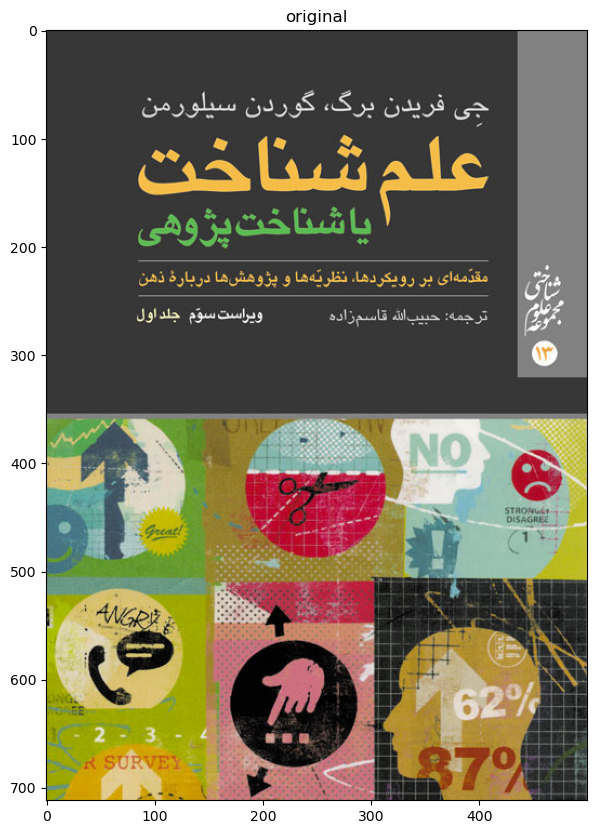

In [3]:
def imshow(title="Image",image=None,size=10):
    w,h=image.shape[0],image.shape[1]
    aspect_ratio=w/h
    plt.figure(figsize=(size*aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()
    
    

image=cv2.imread("C:/Users/Raya-Center/Pictures/Saved Pictures/1470.jpg")
imshow("original",image)

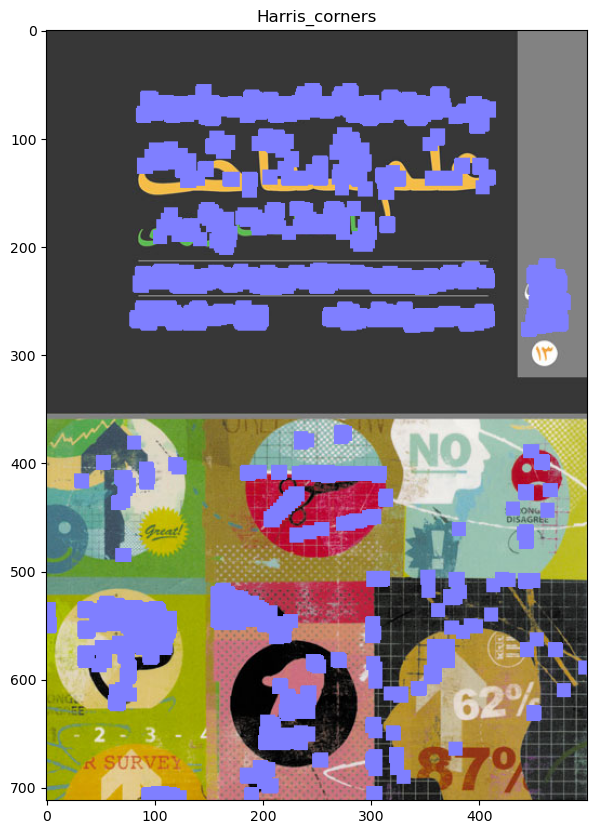

In [5]:
gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
gray=np.float32(gray)
harris_corners=cv2.cornerHarris(gray,3,3,0.05)

kernel=np.ones((7,7),np.uint8)
harris_corners=cv2.dilate(harris_corners,kernel,iterations=2)
image[harris_corners>0.025*harris_corners.max()]=[255,127,127]#threshold=color

imshow("Harris_corners",image)

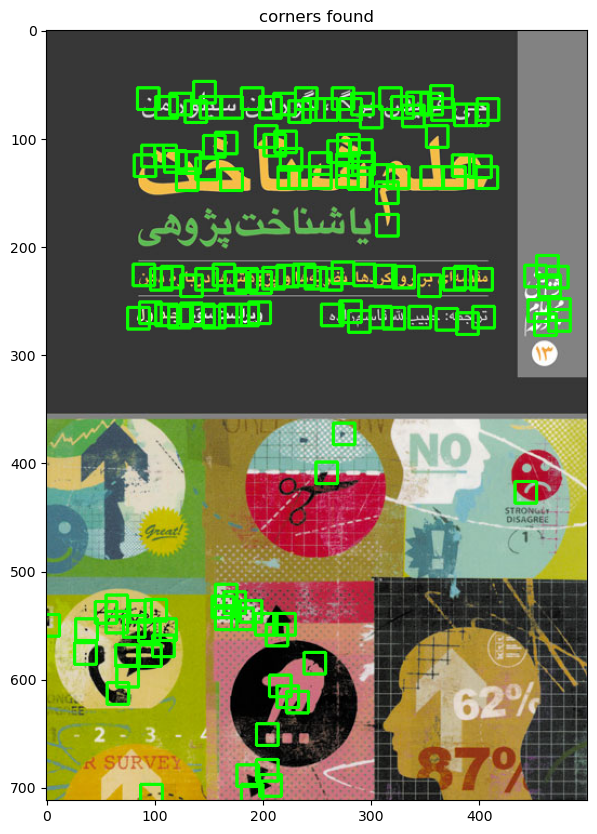

In [6]:
image=cv2.imread("C:/Users/Raya-Center/Pictures/Saved Pictures/1470.jpg")
gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

corners=cv2.goodFeaturesToTrack(gray,150,0.0005,10)

for corner in corners:
    x,y=corner[0]
    x=int(x)
    y=int(y)
    cv2.rectangle(image,(x-10,y-10),(x+10,y+10),(0,255,10),2)
    
imshow("corners found",image)    